# Project 1: House Price Prediction
**SoftGrowTech ML Internship Task 2**  
Dataset loaded directly from: https://raw.githubusercontent.com/Shreyas3108/house-price-prediction/master/kc_house_data.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
url = "https://raw.githubusercontent.com/Shreyas3108/house-price-prediction/master/kc_house_data.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (21613, 21)
Columns: ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Data Preprocessing & Cleaning

Missing values: 0


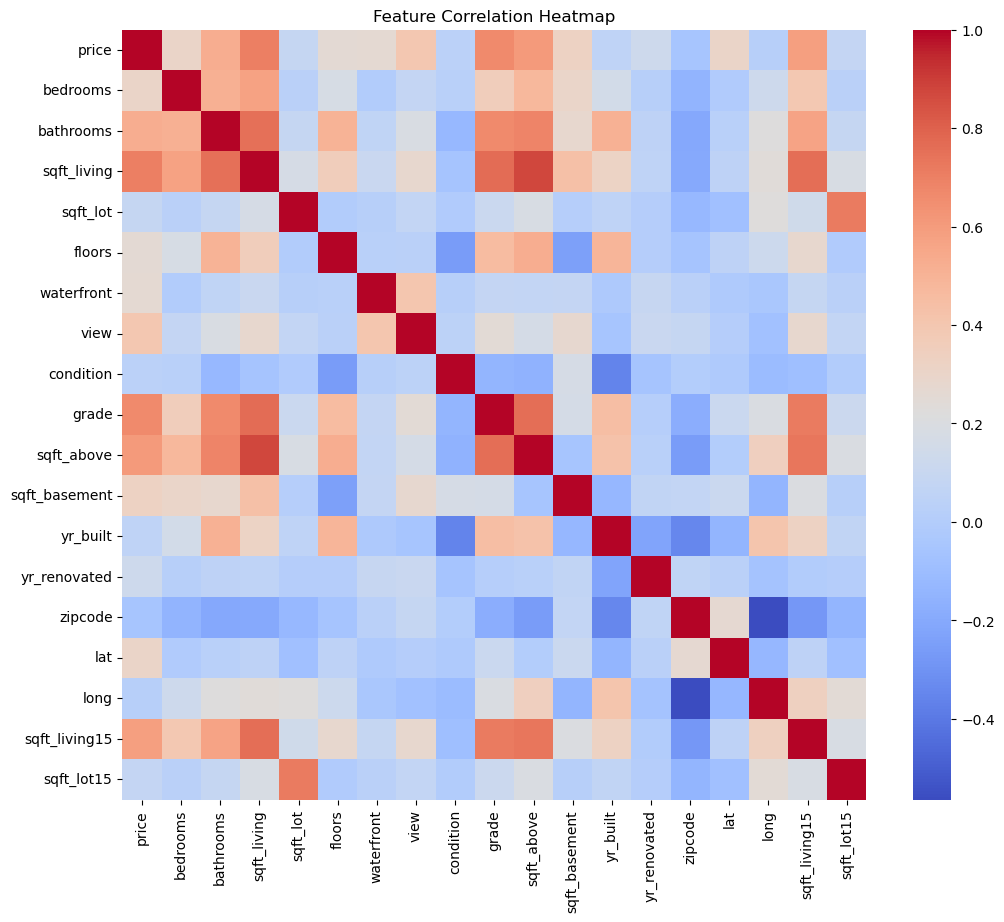

In [3]:
# Drop unnecessary columns
df = df.drop(['id', 'date'], axis=1)

# Check missing values
print("Missing values:", df.isnull().sum().sum())

# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# Features & Target
X = df.drop('price', axis=1)
y = df['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training – Linear Regression

In [4]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

## Model Evaluation

Root Mean Squared Error: $212,539.52
R² Score: 0.7012


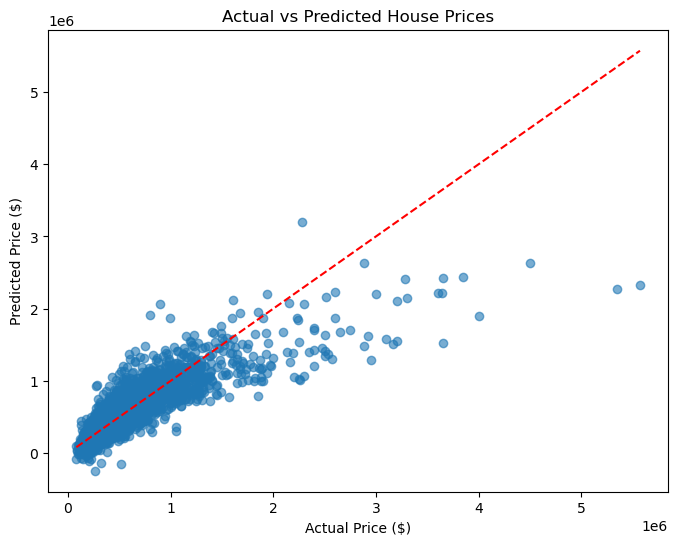

In [5]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error: ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted House Prices')
plt.show()

In [9]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

# 4 simple sliders only
bed = widgets.IntSlider(value=3, min=1, max=10, description='Bedrooms:')
bath = widgets.FloatSlider(value=2.0, min=1, max=5, step=0.25, description='Bathrooms:')
sqft = widgets.IntSlider(value=2000, min=500, max=10000, description='Living Area (sqft):')
year = widgets.IntSlider(value=2000, min=1900, max=2025, description='Year Built:')

output = widgets.Output()

def predict(b):
    with output:
        clear_output()
        data = pd.DataFrame([[bed.value, bath.value, sqft.value, 10000, 1, 0, 0, 3, 7, 
                              sqft.value-200, 200, year.value, 0, 98103, 47.5, -122.3, 
                              sqft.value, 10000]],
                            columns=['bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront',
                                     'view','condition','grade','sqft_above','sqft_basement','yr_built',
                                     'yr_renovated','zipcode','lat','long','sqft_living15','sqft_lot15'])
        
        scaled = scaler.transform(data)
        price = model.predict(scaled)[0]
        print(f"🏠 **Predicted Price: ${price:,.0f}**")

btn = widgets.Button(description="🚀 Predict Price", button_style='success')
btn.on_click(predict)# Change these 4 numbers only ↓
bedrooms = 3
bathrooms = 2.0
living_area = 2000
year_built = 2000

# Do NOT change anything below
data = pd.DataFrame([[bedrooms, bathrooms, living_area, 10000, 1, 0, 0, 3, 7, 
                      living_area-200, 200, year_built, 0, 98103, 47.5, -122.3, 
                      living_area, 10000]],
                    columns=['bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront',
                             'view','condition','grade','sqft_above','sqft_basement','yr_built',
                             'yr_renovated','zipcode','lat','long','sqft_living15','sqft_lot15'])

scaled = scaler.transform(data)
price = model.predict(scaled)[0]

print(f"🏠 Predicted House Price = ${price:,.0f}")

display(bed, bath, sqft, year, btn, output)

🏠 Predicted House Price = $331,587


IntSlider(value=3, description='Bedrooms:', max=10, min=1)

FloatSlider(value=2.0, description='Bathrooms:', max=5.0, min=1.0, step=0.25)

IntSlider(value=2000, description='Living Area (sqft):', max=10000, min=500)

IntSlider(value=2000, description='Year Built:', max=2025, min=1900)

Button(button_style='success', description='🚀 Predict Price', style=ButtonStyle())

Output()